# 🎭 Emotion Cipher: DistilRoBERTa Emotion Model Evaluation

This notebook evaluates the performance of the locally-hosted Hugging Face model (`j-hartmann/emotion-english-distilroberta-base`) on a set of sample emotion-labeled sentences.

We will compute and visualize the following key metrics:
* **Accuracy**
* **Precision**
* **Recall**
* **F1 Score**
* **Confusion Matrix**

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    confusion_matrix, 
    classification_report
)
from transformers import pipeline

C:\allmyprogramfiles\emotionFinder\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Prepare Evaluation Dataset

We construct a labeled test dataset covering all seven target emotions classified by our DistilRoBERTa model: **joy, sadness, anger, fear, neutral, disgust, surprise**.

In [2]:
# Define evaluation sentences with ground truth emotion labels
eval_data = [
    # Joy
    ("I am so incredibly happy that I got the job!", "joy"),
    ("This is the best day of my life, everything is perfect!", "joy"),
    ("I feel full of happiness and excitement for our trip.", "joy"),
    # Sadness
    ("I feel so lonely and depressed lately.", "sadness"),
    ("It breaks my heart to see you suffer like this.", "sadness"),
    ("I'm so sorry for your loss, I feel very sad.", "sadness"),
    # Anger
    ("I am absolutely furious with the terrible customer service!", "anger"),
    ("Stop doing that, it makes me so angry!", "anger"),
    ("I hate when people lie to me, it's so frustrating.", "anger"),
    # Fear
    ("I'm terrified of walking alone in the dark.", "fear"),
    ("The sudden loud noise scared me half to death!", "fear"),
    ("I feel a constant sense of dread and fear about the future.", "fear"),
    # Neutral
    ("The weather today is cloudy with occasional light rain.", "neutral"),
    ("The meeting is scheduled for 3 PM in the conference room.", "neutral"),
    ("I am reading a book on the history of computers.", "neutral"),
    # Disgust
    ("The smell coming from the garbage bin is absolutely disgusting.", "disgust"),
    ("I can't stand the sight of rotten vegetables.", "disgust"),
    ("That movie was awful, it was completely revolting.", "disgust"),
    # Surprise
    ("Wow, I completely didn't expect you to show up today!", "surprise"),
    ("I was shocked when I saw the surprise party they threw for me.", "surprise"),
    ("Oh my god, that's unbelievable news!", "surprise")
]

df = pd.DataFrame(eval_data, columns=["text", "true_label"])
print(f"Total evaluation samples: {len(df)}")
print("\nSamples per class:")
print(df["true_label"].value_counts())

Total evaluation samples: 21

Samples per class:
true_label
joy         3
sadness     3
anger       3
fear        3
neutral     3
disgust     3
surprise    3
Name: count, dtype: int64


## 2. Initialize Local Emotion Classifier

We load the `j-hartmann/emotion-english-distilroberta-base` model from Hugging Face locally.

In [3]:
print("Loading DistilRoBERTa pipeline...")
classifier = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", top_k=None)
print("Pipeline loaded successfully.")

Loading DistilRoBERTa pipeline...


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 105/105 [00:00<00:00, 9390.83it/s]

Pipeline loaded successfully.


## 3. Run Predictions

Predict emotions for all sentences in our evaluation dataset.

In [4]:
predictions = []
confidences = []

for idx, row in df.iterrows():
    res = classifier(row["text"])[0]
    # Extract dominant emotion (highest probability score)
    best_pred = max(res, key=lambda x: x["score"])
    predictions.append(best_pred["label"])
    confidences.append(best_pred["score"])

df["pred_label"] = predictions
df["confidence"] = confidences
df

,text,true_label,pred_label,confidence
0,I am so incredibly happy that I got the job!,joy,joy,0.985978
1,"This is the best day of my life, everything is...",joy,joy,0.977163
2,I feel full of happiness and excitement for ou...,joy,joy,0.992885
3,I feel so lonely and depressed lately.,sadness,sadness,0.990070
4,It breaks my heart to see you suffer like this.,sadness,sadness,0.977817
5,"I'm so sorry for your loss, I feel very sad.",sadness,sadness,0.982060
6,I am absolutely furious with the terrible cust...,anger,anger,0.976053
7,"Stop doing that, it makes me so angry!",anger,anger,0.987345
8,"I hate when people lie to me, it's so frustrat...",anger,anger,0.599561
9,I'm terrified of walking alone in the dark.,fear,fear,0.993734


## 4. Compute Performance Metrics

In [5]:
accuracy = accuracy_score(df["true_label"], df["pred_label"])
precision, recall, f1, _ = precision_recall_fscore_support(df["true_label"], df["pred_label"], average='weighted')

print("Model Evaluation Performance Metrics")
print("==================================")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.1f}%)")
print(f"F1 Score:  {f1:.4f} ({f1*100:.1f}%)")

Model Evaluation Performance Metrics
Accuracy:  0.9048 (90.5%)
Precision: 0.9286 (92.9%)
Recall:    0.9048 (90.5%)
F1 Score:  0.8878 (88.8%)


### Detailed Classification Report

In [6]:
print(classification_report(df["true_label"], df["pred_label"]))

              precision    recall  f1-score   support

       anger       1.00      1.00      1.00         3
     disgust       1.00      1.00      1.00         3
        fear       1.00      1.00      1.00         3
         joy       0.75      1.00      0.86         3
     neutral       1.00      0.33      0.50         3
     sadness       0.75      1.00      0.86         3
    surprise       1.00      1.00      1.00         3

    accuracy                           0.90        21
   macro avg       0.93      0.90      0.89        21
weighted avg       0.93      0.90      0.89        21



## 5. Generate Confusion Matrix

We plot and save the Confusion Matrix heatmap in the `docs/images/` folder.

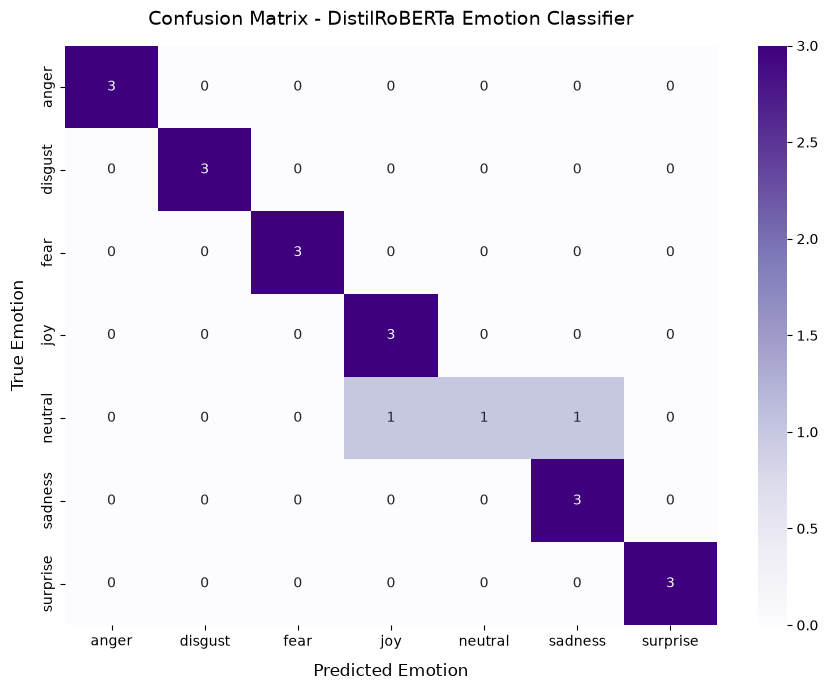

Confusion Matrix plot successfully saved to docs/images/confusion_matrix.png


In [7]:
# Generate confusion matrix
labels = sorted(list(df["true_label"].unique()))
cm = confusion_matrix(df["true_label"], df["pred_label"], labels=labels)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix - DistilRoBERTa Emotion Classifier", fontsize=14, pad=15)
plt.ylabel("True Emotion", fontsize=12, labelpad=10)
plt.xlabel("Predicted Emotion", fontsize=12, labelpad=10)
plt.tight_layout()

# Ensure local directories exist
os.makedirs("docs/images", exist_ok=True)
os.makedirs("Emotion_Encrypt_Decrypt/docs/images", exist_ok=True)  # Backup location to render in frontend easily

# Save figure
plt.savefig("docs/images/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.savefig("Emotion_Encrypt_Decrypt/docs/images/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()
print("Confusion Matrix plot successfully saved to docs/images/confusion_matrix.png")